In [3]:
from scipy import optimize
import os
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import scipy.special as special
from scipy import optimize
from scipy.special import jv
from scipy.optimize import minimize
from scipy.optimize import differential_evolution
import corner
#import multiprocessing
import bilby
from bilby.core.utils.random import rng, seed
from bilby.core.prior import PriorDict, Uniform, Constraint, LogUniform
from bilby.bilby_mcmc.proposals import ProposalCycle, AdaptiveGaussianProposal, PriorProposal
import sys
import argparse
import index_calc


In [6]:
path="lisaHTI/inj_final_100_0_mid_inclin_01/outdir_dynesty/nested_sampling_for_Roemer_Delay_samples.txt"
samples=np.loadtxt(path)
samples

array([[ 2.86488741e+00,  1.00587360e+02,  3.68074856e+00, ...,
         4.03160323e+06, -2.93997126e+03, -4.09126237e-01],
       [ 2.95460495e+00,  1.00417318e+02,  3.59349740e+00, ...,
         4.00995303e+06, -2.93928491e+03, -4.09126237e-01],
       [ 3.00694093e+00,  1.00520769e+02,  3.54118424e+00, ...,
         4.02086911e+06, -2.93842722e+03, -4.09126237e-01],
       ...,
       [ 3.02425920e+00,  1.00527320e+02,  3.52290673e+00, ...,
         4.02289869e+06, -2.92283382e+03, -4.09126237e-01],
       [ 3.02224053e+00,  1.00410764e+02,  3.52471473e+00, ...,
         4.00933992e+06, -2.92281533e+03, -4.09126237e-01],
       [ 3.04268681e+00,  1.00145282e+02,  3.50455260e+00, ...,
         3.97716594e+06, -2.92274843e+03, -4.09126237e-01]],
      shape=(12316, 11))

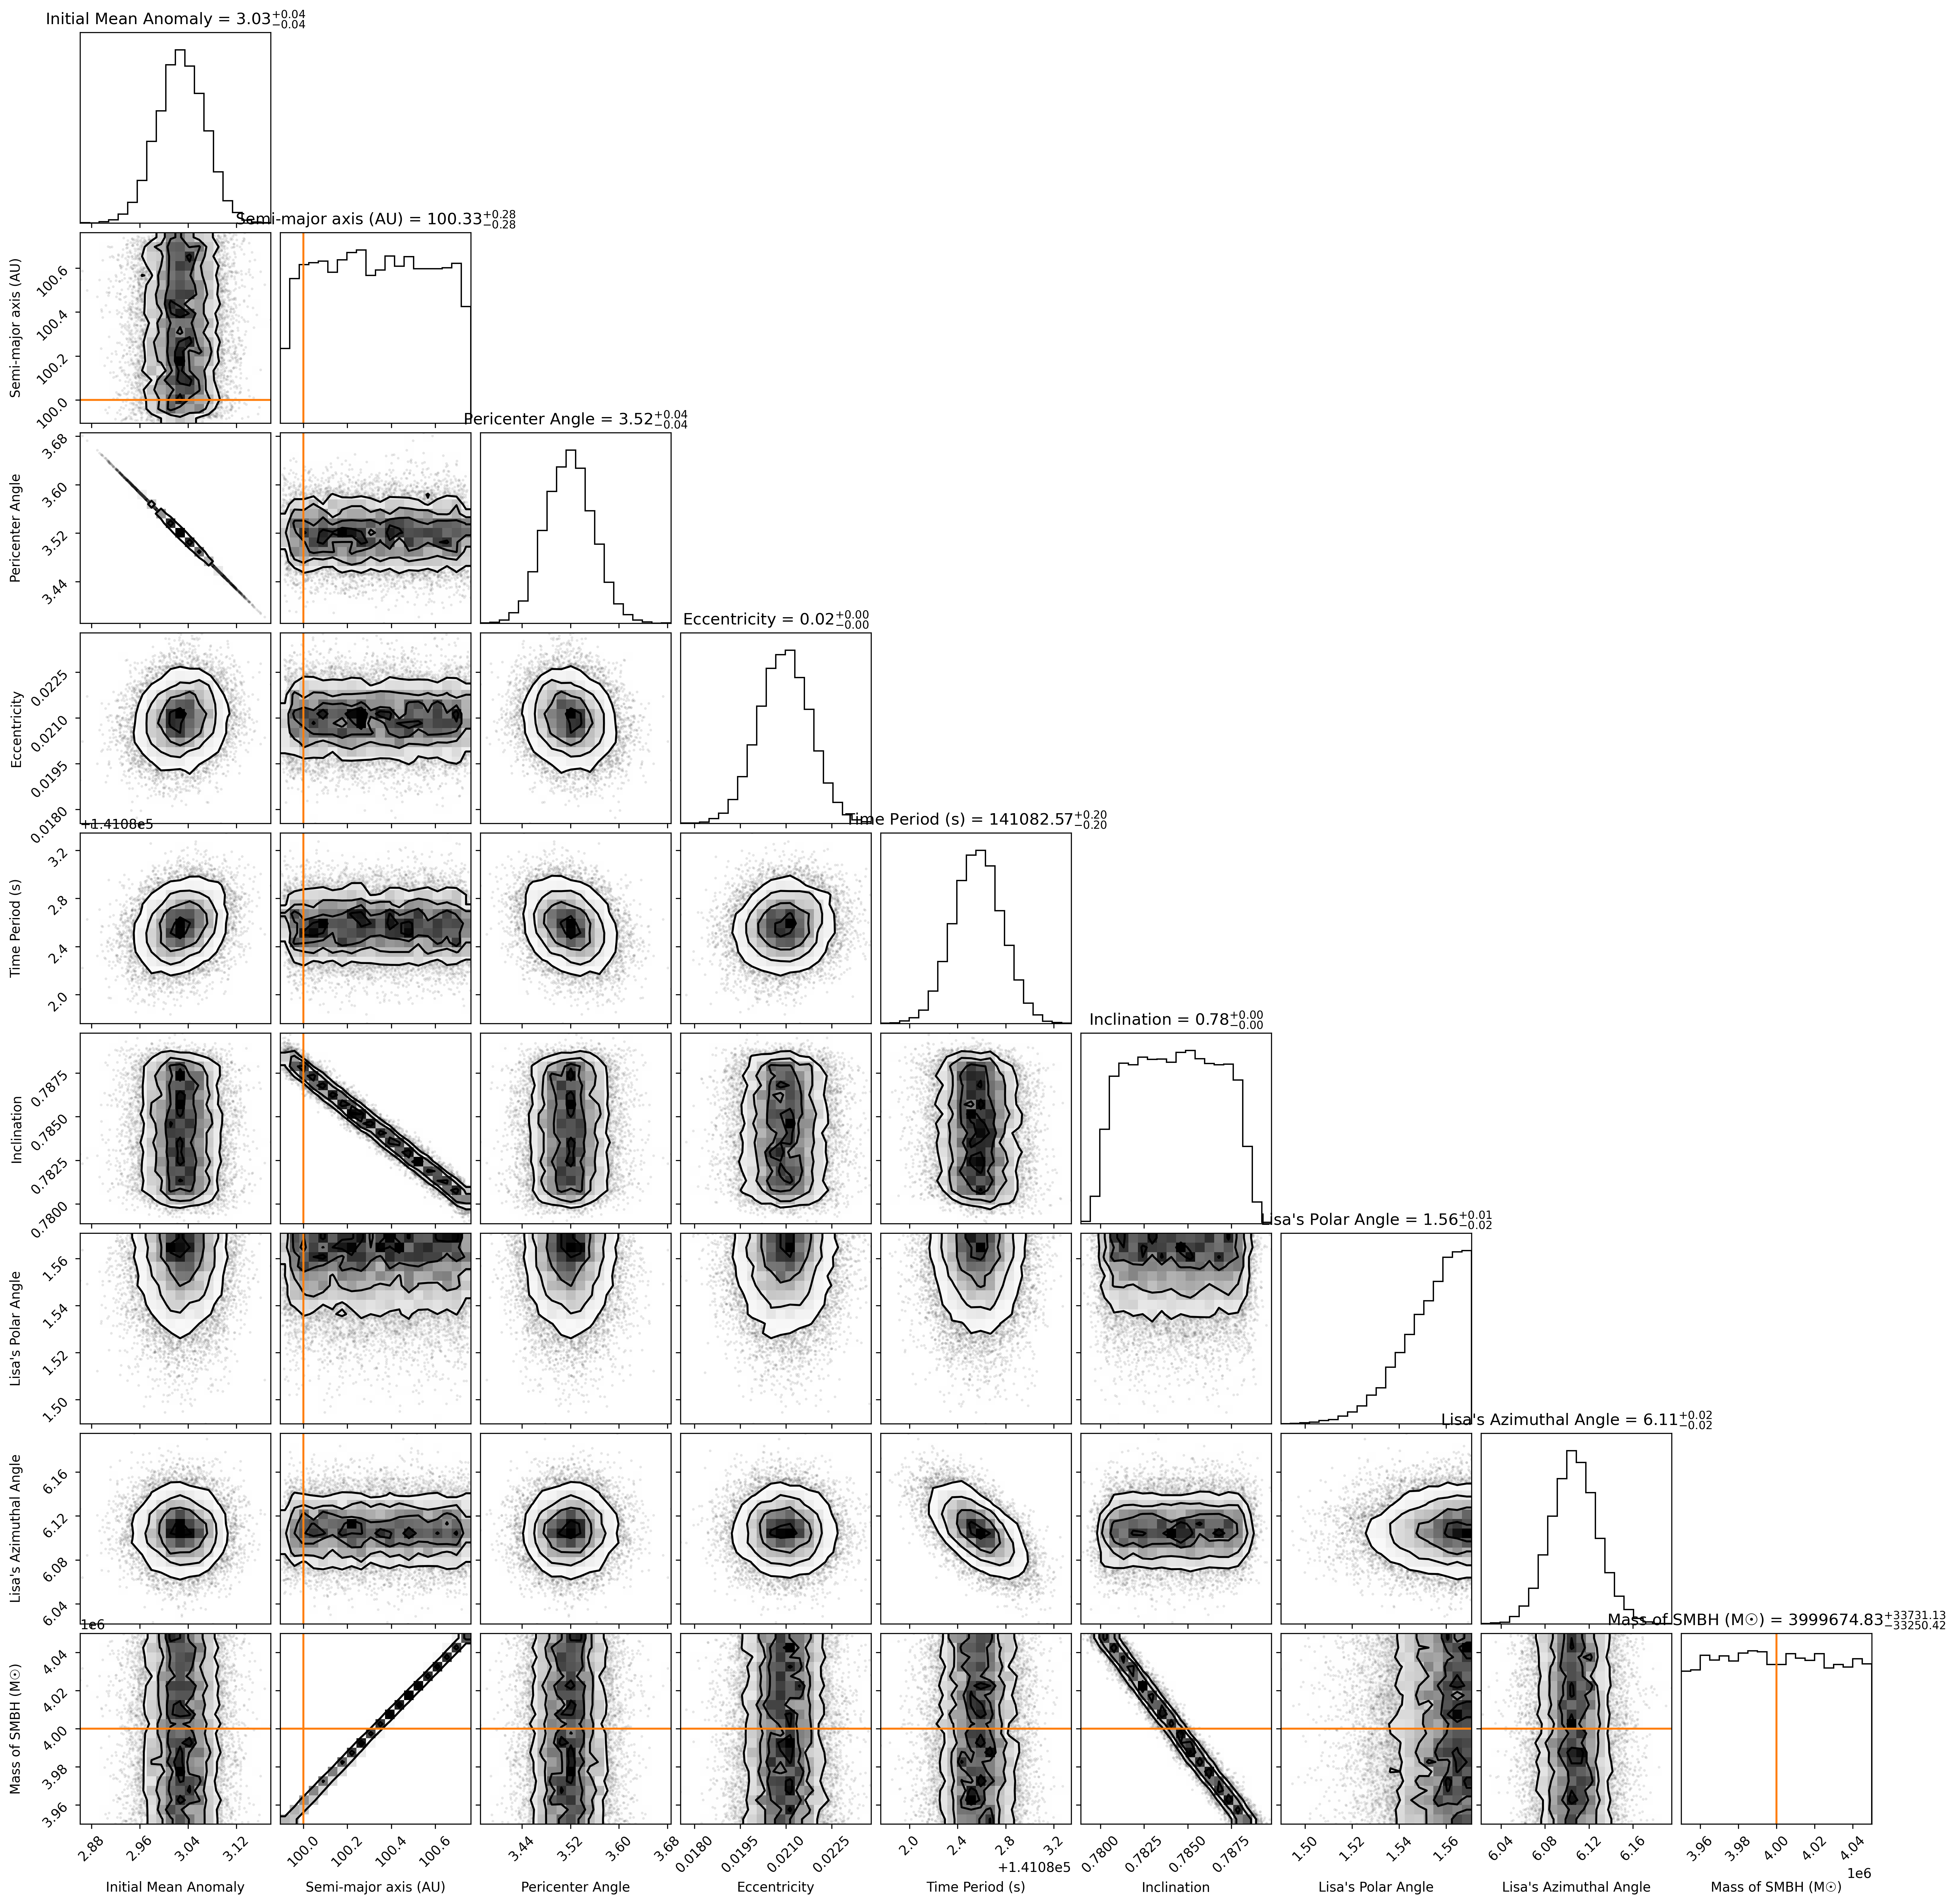

In [17]:
time_samples=np.loadtxt("lisaHTI/inj_final_100_0_mid_inclin_01/inj_final_100_0_mid_inclin_01_triggers_refined.dat")
t_start=time_samples[0,0]
pd.DataFrame(time_samples)

,0,1,2,3,4,5,6
0,5.568688e+05,0.005556,8.789062,0.005476,3.596270,74.572551,8.577444
1,6.961188e+05,0.005667,8.789062,0.004751,4.228347,104.017186,10.149738
2,8.353862e+05,0.005889,8.789062,0.005805,3.596270,99.062077,9.902630
3,9.747050e+05,0.005556,8.789062,0.005476,3.596270,130.116595,11.362948
4,1.114059e+06,0.005556,8.789062,0.005476,3.596270,257.809249,16.025269
...,...,...,...,...,...,...,...
207,3.021073e+07,0.005667,8.789062,0.004751,4.228347,220.951896,14.830775
208,3.035008e+07,0.005889,8.789062,0.005805,3.596270,170.457410,13.017581
209,3.048939e+07,0.005889,8.789062,0.005805,3.596270,169.662590,12.987016
210,3.062866e+07,0.005556,8.789062,0.005476,3.596270,117.581310,10.797283


In [23]:
1.273387878906250000e+07/3.154e+7

0.40373743782696575

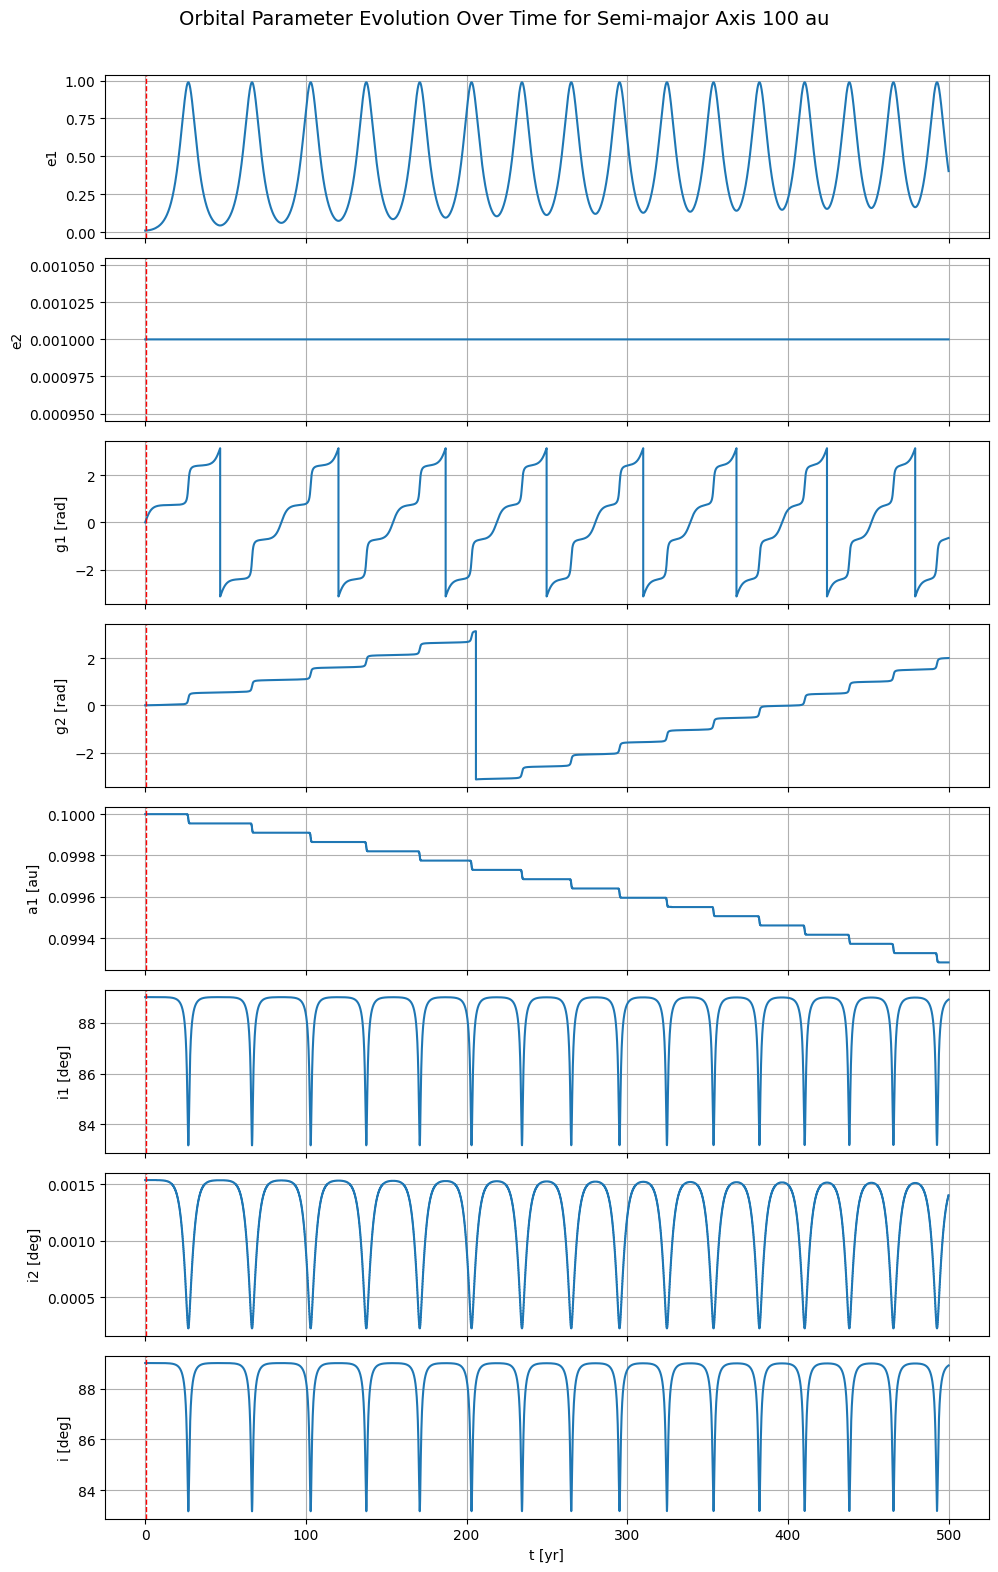

In [24]:
path_orbit = np.loadtxt("results/inj_final_100_0_ospe.txt")

labels = ['e1', 'e2', 'g1 [rad]', 'g2 [rad]', 'a1 [au]', 
          'i1 [deg]', 'i2 [deg]', 'i [deg]']

# --- Set your vertical-line location ---
t_start = 0.40  # or set manually, e.g., t_start = 100.0

# Create subplots (8 rows, 1 column)
fig, axes = plt.subplots(8, 1, figsize=(10, 16), sharex=True)

# Plot each parameter and vertical line
for i in range(8):
    axes[i].plot(path_orbit[:, 0], path_orbit[:, i + 1])
    axes[i].axvline(t_start, color='r', linestyle='--', linewidth=1)
    axes[i].set_ylabel(labels[i])
    axes[i].grid(True)

# Common x-label
axes[-1].set_xlabel('t [yr]')

plt.suptitle('Orbital Parameter Evolution Over Time for Semi-major Axis 100 au', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [21]:
path_orbit[:,0]

array([0.00000e+00, 1.00000e-03, 1.00000e-03, ..., 5.00000e+02,
       5.00000e+02, 5.00001e+02], shape=(1000002,))